<a href="https://colab.research.google.com/github/Soumo31428/Multiple-Linear-Regression-Economics-Dataset/blob/main/Multiple_Linear_Regression_Economics_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_index = pd.read_csv('/content/modified_synthetic_economic_data.csv')
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,1924,1,3.50,5.19,534.714897
1,1925,1,2.86,4.36,424.911412
2,1926,1,3.65,5.18,582.253910
3,1927,1,4.52,5.81,784.797318
4,1928,1,2.77,5.07,321.169866


In [4]:
## Drop unnecessary columns
df = df_index.drop(columns = [ 'year', 'month'],axis=1,inplace = False)[:100]
df.shape

(100, 3)

In [5]:
## Check null values
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


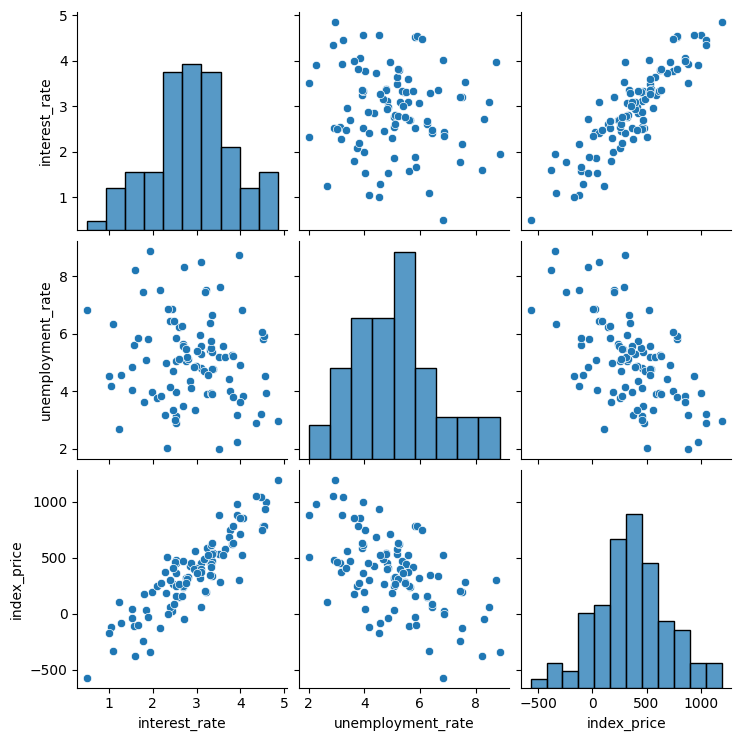

In [6]:
## Visualize the data
import seaborn as sns
sns.pairplot(df)

In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.116647,0.883585
unemployment_rate,-0.116647,1.000000,-0.568142
index_price,0.883585,-0.568142,1.000000


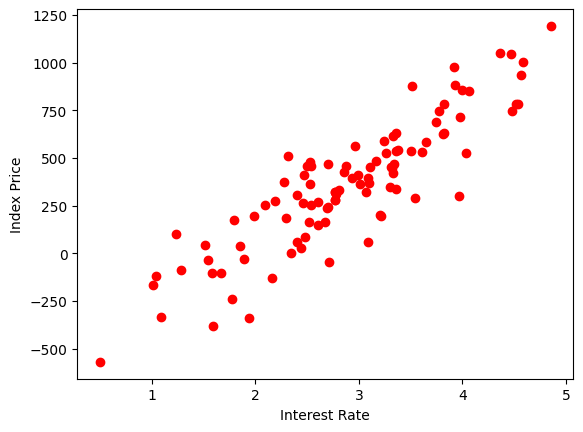

In [8]:
## Visualize the Datapoints more closely
plt.scatter(df['interest_rate'],df['index_price'], color = 'red')
plt.xlabel('Interest Rate')
plt.ylabel('Index Price')
plt.show()

In [9]:
## Independent and Dependent features
x = df[['interest_rate','unemployment_rate']]     # or df.iloc[:,:-1]
y = df['index_price']     # df.iloc[:,-1]

In [10]:
# train test split
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2,random_state = 0)

<Axes: xlabel='interest_rate', ylabel='index_price'>

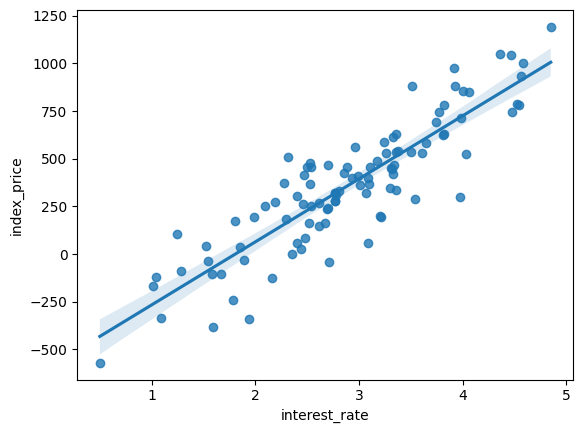

In [11]:
import seaborn as sns
sns.regplot(x = 'interest_rate',y = 'index_price',data = df)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

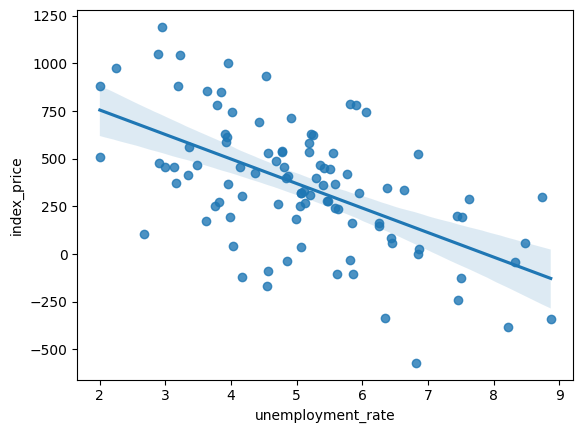

In [12]:
sns.regplot(x = 'unemployment_rate',y = 'index_price',data = df)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
ytrain = scaler.fit_transform(ytrain.values.reshape(-1, 1))

In [15]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(xtrain, ytrain)

LinearRegression()

In [16]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(reg,xtrain,ytrain,scoring='neg_mean_squared_error', cv=5)

In [17]:
validation_score

array([-7.31621181e-08, -7.66245719e-07, -9.68490646e-08, -1.34682487e-06,
       -9.53536818e-08])

In [18]:
## prediction
ypred = reg.predict(xtest)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [29]:
print(reg.coef_)
print(reg.intercept_)

[[ 0.83698005 -0.48621821]]
[-7.36100015e-18]


In [22]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(ytest,ypred)
mae = mean_absolute_error(ytest,ypred)
r2 = r2_score(ytest,ypred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(r2)
print(rmse)

270760.0640008574
442.26952641341825
-1.0272308558769492
520.3461002072154


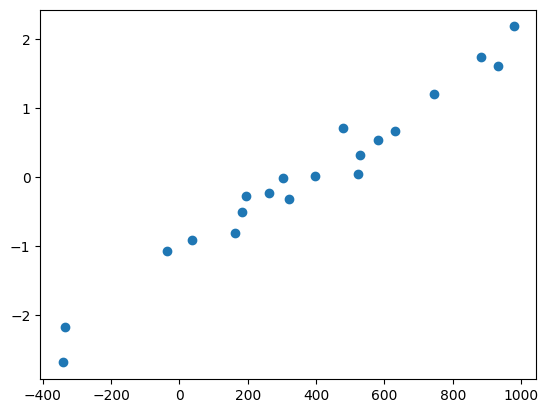

In [23]:
## Assumptions
plt.scatter(ytest,ypred)

26     36.968663
86    976.329104
2     581.717544
55    879.670916
75    631.137789
93    164.147460
16    194.881015
73    932.196461
54    522.986008
95    -35.577044
53    529.058072
92    184.541353
78    396.982943
13   -332.911731
7     743.097677
30    303.571767
22    320.660983
24    262.645028
33   -338.685188
8     477.623782
Name: index_price, dtype: float64


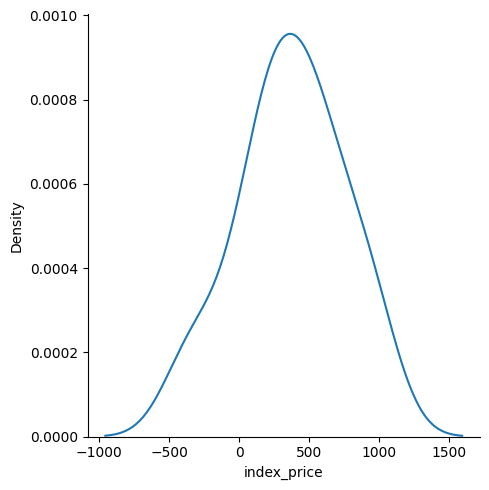

In [26]:
residuals = ytest - ypred.flatten()
print(residuals)
## plot this residuals
sns.displot(residuals, kind = 'kde')

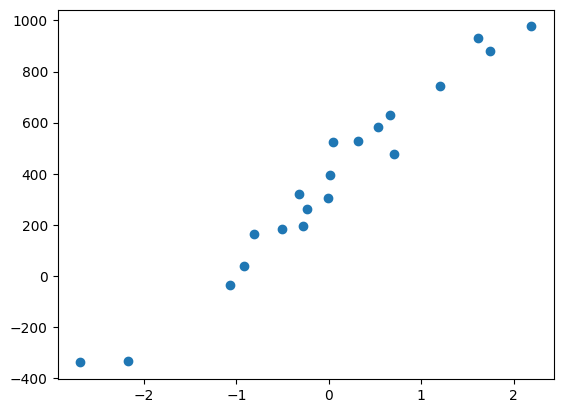

In [27]:
## scatter plot with respect to prediction and residuals
plt.scatter(ypred, residuals)

In [28]:
## OLS Linear Regression
import statsmodels.api as sm
model =  sm.OLS(ytrain, xtrain).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          9.628e+07
Date:                Wed, 12 Feb 2025   Prob (F-statistic):                   4.93e-250
Time:                        13:05:22   Log-Likelihood:                          475.25
No. Observations:                  80   AIC:                                     -946.5
Df Residuals:                      78   BIC:                                     -941.7
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8370   7.23e-05   1.16e+04      0.000       0.837       0.837
x2            -0.4862   7.23e-05  -6726.884      0.000      -0.486      -0.486
==============================================================================
Omnibus:                       81.745   Durbin-Watson:                   1.851
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3009.418
Skew:                           2.408   Prob(JB):                         0.00
Kurtosis:                      32.659   Cond. No.                         1.08
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""